In [46]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
# value object
class Value():
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._backward = lambda: None
        self._prev=set(_children)# children was empty tupple initially
        self._op=_op
        self.label=label

    def __repr__(self):# gives a readable output nothing else
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other= other if isinstance(other, Value) else Value(other) # to allow expressions like a+1
        out= Value(self.data + other.data, (self, other),'+')

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
      
        return out
    
    def __mul__(self,other):
        other= other if isinstance(other, Value) else Value(other)
        out= Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def tanh(self):# nothing but a squashing function
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out =Value(t, (self,),'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward = _backward # store the function not call the function
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad # out.grad is for cases if power is also an expression of x
        out._backward = _backward
        return out # always return value otherwise you will get TypeError: unsupported operand type(s) for *: 'float' and 'NoneType' or something similar
        
        # Multiply by out.grad because this node may not be the final output.
        # Example: y = x**2, L = y**3
        # dL/dx = (dL/dy) * (dy/dx)
        # out.grad stores dL/dy (upstream gradient),
        # while other * x**(other-1) is dy/dx (local derivative).
        # Their product is the chain rule.


    def __rmul__(self,other): # python still doesnt understand 2*a because that literally translates to 2.__mul__ (a) so __rmul__ makes python check if its a value object and then do a.__mul__(2) even for 2*a
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1 # a/b = a*(1/b)= a*b**-1 (using this because its more general and we can make division as a special case of power)
    

    def __neg__(self ):
        return self*-1
    
    def __sub__(self, other):
        return self + (-other)
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data*out.grad # d/dx(e^nx)= n*e^nx 
        out._backward=_backward
        
        return out


    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

In [48]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot


In [49]:
# x1 = Value(2.0, label='x1')
# x2 = Value(0.0, label='x2')
# # weights w1,w2
# w1 = Value(-3.0, label='w1')
# w2 = Value(1.0, label='w2')
# # bias of the neuron
# b = Value(6.8813735870195432, label='b')
# # x1*w1 + x2*w2 + b
# x1w1 = x1*w1; x1w1.label = 'x1*w1'
# x2w2 = x2*w2; x2w2.label = 'x2*w2'
# x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'


In [50]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# implementing tanh as exp
e = (2*n).exp()
o = (e - 1) / (e + 1); o.label ='o'


In [51]:
o.backward()

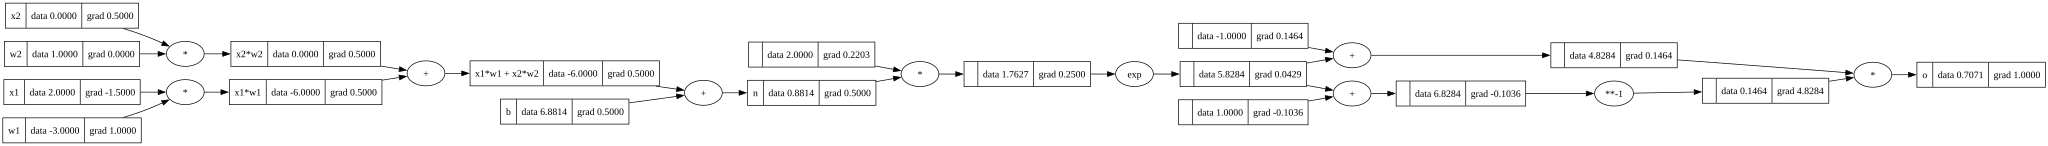

In [52]:
draw_dot(o)

In [53]:
# import sys
# !{sys.executable} -m pip install torch

In [54]:
import torch 
#torch.Tensor([array or value]).dataype and torch assumes gradient is not required so you have to set them true manually
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True # tensors are just n dimensional arrays of scalars
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())#.item takes tensor of one element and returns the element after stripping the tensor
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())
# o
# o.item()

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [55]:
class Neuron:

    def __init__(self, nin):# constructor takes number of inputs to neuron then create weight and bias 
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self,x):
        # w*x(dot prod) + b
        act=sum ((wi*xi for wi,xi in zip(self.w,x)),self.b) # the second argument tells where to start so just add b first and then add wi*xi on top of that
        out =act.tanh()
        return out
    
    def parameters(self):
        return self.w +[self.b]
    
# a layer is a list of neurons and how many neurons can be taken as a arguement
class Layer:
  
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
  
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # to return a single element if its only one value for the output rather than the entire list
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params =[]
        # for neuron in self.neurons:
        #     ps=neuron.parameters()
        #     params.extend(ps)
        # return params
            
# MLP is multi layer perceptron where one layer feeds into the other
class MLP:
  
    def __init__(self, nin, nouts): # take list of n outs that defines the sizes of all the layers in the MLP
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # iterate over consecutive pairs of sizes and create layers 
  
    def __call__(self, x): # to call sequencially
        for layer in self.layers:
            x = layer(x)
        return x
  
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [56]:
x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=-0.8779384193115195)

In [57]:
len(n.parameters())

41

In [58]:
# draw_dot(m(y))

In [113]:
# doing an example 
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
ypred=[n(x) for x in xs]
# ypred
# single number that tells how a nn is performing 
# here using mean squared error
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)),Value(0.0)) 
loss # low loss means predictions are getting closer to target

Value(data=0.643326845091492)

In [ ]:
# loss.backward()


In [62]:
n.layers[0].neurons[0].w[0].grad

-0.4860098082478686

In [65]:
n.layers[0].neurons[0].w[0].data

-0.9967934026255552

In [63]:
# draw_dot(loss)

In [105]:
for p in n.parameters(): #gradient descent
    p.data+= -0.01*p.grad # -learning rate*gradient for the negative sign use the above grad and data to make sense
    # think of grad vector in the direction of increasing loss

    # forward pass -> backward pass -> update


In [ ]:
ypred # almost perfect now
# now use n.parameters to fix weights

[Value(data=0.8824028562114007),
 Value(data=-0.9883851851635247),
 Value(data=-0.22101395392126308),
 Value(data=0.8498547604644561)]

In [114]:
# do it all at once
for k in range(10):
    # forward pass
    ypred=[n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)),Value(0.0)) 
    #backward pass
    for p in n.parameters():
        p.grad=0.0 # zerograd bug 
    loss.backward()
    #update
    for p in n.parameters(): #gradient descent
        p.data+= -0.05*p.grad
    print(k,loss.data)

0 0.0015383679291873574
1 0.0015291896412552215
2 0.0015201196267069267
3 0.0015111559856904968
4 0.0015022968624788479
5 0.0014935404441974811
6 0.0014848849595956739
7 0.00147632867786007
8 0.001467869907468102
9 0.0014595069950805897


In [115]:
ypred

[Value(data=1.0),
 Value(data=-0.9729860499456248),
 Value(data=-0.9729860499456242),
 Value(data=1.0)]